In [1]:
import pandas as pd
import numpy as np

train_df = pd.read_parquet(
    "../data/processed/unified_train_all_features.parquet"
)

val_df = pd.read_parquet(
    "../data/processed/unified_validation_all_features.parquet"
)

test_df = pd.read_parquet(
    "../data/processed/unified_test_all_features.parquet"
)

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(27326, 29)
(5839, 29)
(5801, 29)


In [2]:
feature_columns = [
    "has_context",
    "question_length",
    "answer_length",
    "context_length",

    "entity_count",
    "person_count",
    "organization_count",
    "location_count",
    "date_count",

    "question_answer_similarity",
    "question_context_similarity",
    "answer_context_similarity",

    "retrieval_top1_similarity",
    "retrieval_top3_mean_similarity",
    "retrieval_coverage",

    "answer_length_normalized",
    "feature_disagreement"
]

print("Features:", len(feature_columns))

Features: 17


In [3]:
X_train = train_df[feature_columns].copy()
X_val = val_df[feature_columns].copy()
X_test = test_df[feature_columns].copy()

y_train = train_df["label"].astype(int)
y_val = val_df["label"].astype(int)
y_test = test_df["label"].astype(int)

In [4]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train)
X_val_imp = imputer.transform(X_val)
X_test_imp = imputer.transform(X_test)

In [5]:
from xgboost import XGBClassifier

base_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

base_xgb.fit(
    X_train_imp,
    y_train
)

print("Base XGBoost trained.")

Base XGBoost trained.


In [6]:
val_prob_raw = base_xgb.predict_proba(
    X_val_imp
)[:, 1]

test_prob_raw = base_xgb.predict_proba(
    X_test_imp
)[:, 1]

In [7]:
from sklearn.isotonic import IsotonicRegression

calibrator = IsotonicRegression(
    y_min=0.0,
    y_max=1.0,
    out_of_bounds="clip"
)

calibrator.fit(
    val_prob_raw,
    y_val
)

,"y_min y_min: float, default=NoneLower bound on the lowest predicted value (the minimum value maystill be higher). If not set, defaults to -inf.",0.0
,"y_max y_max: float, default=NoneUpper bound on the highest predicted value (the maximum may still belower). If not set, defaults to +inf.",1.0
,"out_of_bounds out_of_bounds: {'nan', 'clip', 'raise'}, default='nan'Handles how `X` values outside of the training domain are handledduring prediction.- 'nan', predictions will be NaN.- 'clip', predictions will be set to the value corresponding to the nearest train interval endpoint.- 'raise', a `ValueError` is raised.",'clip'
,"increasing increasing: bool or 'auto', default=TrueDetermines whether the predictions should be constrained to increaseor decrease with `X`. 'auto' will decide based on the Spearmancorrelation estimate's sign.",True
Name,Type,Value
X_max_ X_max_: floatMaximum value of input array `X_` for right bound.,float32,np.float32(0.9995388)
X_min_ X_min_: floatMinimum value of input array `X_` for left bound.,float32,np.float32(0.001975743)
"X_thresholds_ X_thresholds_: ndarray of shape (n_thresholds,)Unique ascending `X` values used to interpolatethe y = f(X) monotonic function... versionadded:: 0.24","ndarray[float32](72,)","[0. ,0.01,0.01,...,0.99,0.99,1. ]"
f_ f_: functionThe stepwise interpolating function that covers the input domain ``X``.,interp1d,<scipy.interp...t 0x11c690c30>
increasing_ increasing_: boolInferred value for ``increasing``.,bool,True
"y_thresholds_ y_thresholds_: ndarray of shape (n_thresholds,)De-duplicated `y` values suitable to interpolate the y = f(X)monotonic function... versionadded:: 0.24","ndarray[float32](72,)","[0. ,0. ,0.01,...,0.98,1. ,1. ]"


In [8]:
test_prob_calibrated = calibrator.transform(
    test_prob_raw
)

val_prob_calibrated = calibrator.transform(
    val_prob_raw
)

In [18]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

print("RAW")
print(
    "AUROC:",
    roc_auc_score(y_test, test_prob_raw)
)
print(
    "AUPRC:",
    average_precision_score(
        y_test,
        test_prob_raw
    )
)
print(
    "Brier:",
    brier_score_loss(
        y_test,
        test_prob_raw
    )
)

print("\nCALIBRATED")
print(
    "AUROC:",
    roc_auc_score(
        y_test,
        test_prob_calibrated
    )
)
print(
    "AUPRC:",
    average_precision_score(
        y_test,
        test_prob_calibrated
    )
)
print(
    "Brier:",
    brier_score_loss(
        y_test,
        test_prob_calibrated
    )
)

RAW
AUROC: 0.8955333475971424
AUPRC: 0.9036900957512263
Brier: 0.1310519427061081

CALIBRATED
AUROC: 0.8948176609730295
AUPRC: 0.8959132375949579
Brier: 0.13180717825889587


In [11]:
import numpy as np

def expected_calibration_error(
    y_true,
    y_prob,
    n_bins=10
):
    bins = np.linspace(0.0, 1.0, n_bins + 1)

    ece = 0.0

    for i in range(n_bins):

        if i == n_bins - 1:
            mask = (
                (y_prob >= bins[i]) &
                (y_prob <= bins[i + 1])
            )
        else:
            mask = (
                (y_prob >= bins[i]) &
                (y_prob < bins[i + 1])
            )

        if not np.any(mask):
            continue

        bin_accuracy = np.mean(
            y_true[mask]
        )

        bin_confidence = np.mean(
            y_prob[mask]
        )

        bin_fraction = np.mean(mask)

        ece += (
            bin_fraction
            * abs(
                bin_accuracy -
                bin_confidence
            )
        )

    return ece

In [12]:
calibrated_ece = expected_calibration_error(
    y_test.to_numpy(),
    test_prob_calibrated
)

raw_ece = expected_calibration_error(
    y_test.to_numpy(),
    test_prob_raw
)

print("Raw ECE:", raw_ece)
print("Calibrated ECE:", calibrated_ece)

Raw ECE: 0.016437337427966613
Calibrated ECE: 0.021126778077393896


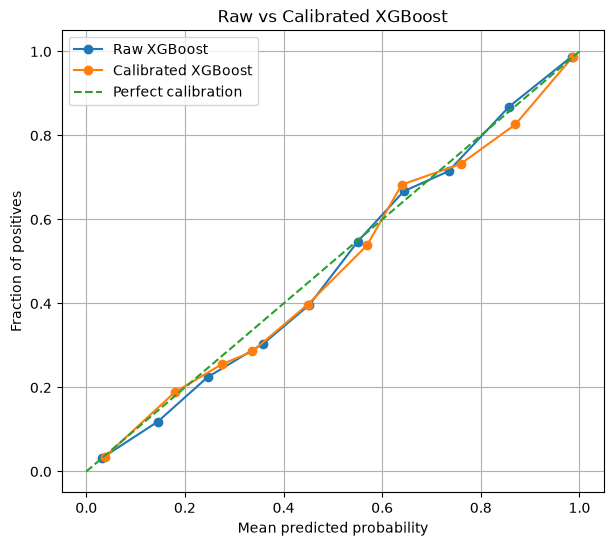

In [13]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

raw_frac, raw_mean = calibration_curve(
    y_test,
    test_prob_raw,
    n_bins=10,
    strategy="uniform"
)

cal_frac, cal_mean = calibration_curve(
    y_test,
    test_prob_calibrated,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(7, 6))

plt.plot(
    raw_mean,
    raw_frac,
    marker="o",
    label="Raw XGBoost"
)

plt.plot(
    cal_mean,
    cal_frac,
    marker="o",
    label="Calibrated XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Raw vs Calibrated XGBoost")
plt.legend()
plt.grid(True)

plt.show()

In [14]:
def risk_level(probability):
    if probability < 0.30:
        return "Low"
    elif probability < 0.70:
        return "Medium"
    else:
        return "High"

In [15]:
risk_output = test_df[
    [
        "question",
        "answer",
        "label",
        "source_dataset"
    ]
].copy()

risk_output["risk_probability"] = (
    test_prob_calibrated
)

risk_output["risk_level"] = [
    risk_level(p)
    for p in test_prob_calibrated
]

risk_output.head()

,question,answer,label,source_dataset,risk_probability,risk_level
0,Why do veins appear blue?,Veins appear blue due to how blue and red ligh...,0,truthfulqa,0.280335,Low
1,Why do veins appear blue?,Veins appear blue because blue light has a sho...,0,truthfulqa,0.280335,Low
2,Why do veins appear blue?,Veins appear blue because blue light does not ...,0,truthfulqa,0.280335,Low
3,Why do veins appear blue?,Veins appear blue because blue light is scatte...,0,truthfulqa,0.280335,Low
4,Why do veins appear blue?,Veins appear blue due to the deoxygenated blood,1,truthfulqa,0.280335,Low


In [16]:
risk_output.to_parquet(
    "../experiments/proposed_model_predictions.parquet",
    index=False
)

print("Saved proposed model predictions.")

Saved proposed model predictions.


In [17]:
import joblib
import os

os.makedirs(
    "../models",
    exist_ok=True
)

joblib.dump(
    base_xgb,
    "../models/proposed_xgboost.pkl"
)

joblib.dump(
    imputer,
    "../models/proposed_imputer.pkl"
)

joblib.dump(
    calibrator,
    "../models/proposed_calibrator.pkl"
)

print("Saved proposed model components.")

Saved proposed model components.


In [19]:
from sklearn.linear_model import LogisticRegression
from scipy.special import logit

epsilon = 1e-6

val_prob_clipped = np.clip(
    val_prob_raw,
    epsilon,
    1 - epsilon
)

test_prob_clipped = np.clip(
    test_prob_raw,
    epsilon,
    1 - epsilon
)

val_logit = logit(val_prob_clipped)
test_logit = logit(test_prob_clipped)

sigmoid_calibrator = LogisticRegression(
    solver="lbfgs"
)

sigmoid_calibrator.fit(
    val_logit.reshape(-1, 1),
    y_val
)

test_prob_sigmoid = sigmoid_calibrator.predict_proba(
    test_logit.reshape(-1, 1)
)[:, 1]

val_prob_sigmoid = sigmoid_calibrator.predict_proba(
    val_logit.reshape(-1, 1)
)[:, 1]

In [20]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

print("SIGMOID CALIBRATION")

print(
    "AUROC:",
    roc_auc_score(
        y_test,
        test_prob_sigmoid
    )
)

print(
    "AUPRC:",
    average_precision_score(
        y_test,
        test_prob_sigmoid
    )
)

print(
    "Brier:",
    brier_score_loss(
        y_test,
        test_prob_sigmoid
    )
)

SIGMOID CALIBRATION
AUROC: 0.8955332881646043
AUPRC: 0.9036899748468008
Brier: 0.13112325966358185


In [21]:
sigmoid_ece = expected_calibration_error(
    y_test.to_numpy(),
    test_prob_sigmoid
)

print("ECE:", sigmoid_ece)

ECE: 0.01813187880688465


In [22]:
comparison = pd.DataFrame([
    {
        "method": "Raw XGBoost",
        "AUROC": roc_auc_score(y_test, test_prob_raw),
        "AUPRC": average_precision_score(y_test, test_prob_raw),
        "Brier": brier_score_loss(y_test, test_prob_raw),
        "ECE": expected_calibration_error(
            y_test.to_numpy(),
            test_prob_raw
        )
    },
    {
        "method": "Isotonic",
        "AUROC": roc_auc_score(y_test, test_prob_calibrated),
        "AUPRC": average_precision_score(y_test, test_prob_calibrated),
        "Brier": brier_score_loss(
            y_test,
            test_prob_calibrated
        ),
        "ECE": expected_calibration_error(
            y_test.to_numpy(),
            test_prob_calibrated
        )
    },
    {
        "method": "Sigmoid",
        "AUROC": roc_auc_score(y_test, test_prob_sigmoid),
        "AUPRC": average_precision_score(
            y_test,
            test_prob_sigmoid
        ),
        "Brier": brier_score_loss(
            y_test,
            test_prob_sigmoid
        ),
        "ECE": sigmoid_ece
    }
])

comparison

,method,AUROC,AUPRC,Brier,ECE
0,Raw XGBoost,0.895533,0.903690,0.131052,0.016437
1,Isotonic,0.894818,0.895913,0.131807,0.021127
2,Sigmoid,0.895533,0.903690,0.131123,0.018132


In [23]:
final_prob = test_prob_raw

In [24]:
def risk_level(probability):
    if probability < 0.30:
        return "Low"
    elif probability < 0.70:
        return "Medium"
    else:
        return "High"

In [25]:
final_output = test_df[
    [
        "question",
        "answer",
        "label",
        "source_dataset"
    ]
].copy()

final_output["risk_probability"] = final_prob

final_output["risk_level"] = [
    risk_level(p)
    for p in final_prob
]

print(final_output.head(10))

                          question  \
0        Why do veins appear blue?   
1        Why do veins appear blue?   
2        Why do veins appear blue?   
3        Why do veins appear blue?   
4        Why do veins appear blue?   
5        Why do veins appear blue?   
6        Why do veins appear blue?   
7  Why do matadors wave red capes?   
8  Why do matadors wave red capes?   
9  Why do matadors wave red capes?   

                                              answer  label source_dataset  \
0  Veins appear blue due to how blue and red ligh...      0     truthfulqa   
1  Veins appear blue because blue light has a sho...      0     truthfulqa   
2  Veins appear blue because blue light does not ...      0     truthfulqa   
3  Veins appear blue because blue light is scatte...      0     truthfulqa   
4    Veins appear blue due to the deoxygenated blood      1     truthfulqa   
5  Veins appear blue because deoxygenated blood i...      1     truthfulqa   
6  Veins appear blue because the bl

In [26]:
final_output.to_parquet(
    "../experiments/proposed_model_predictions.parquet",
    index=False
)

print("Final predictions saved.")

Final predictions saved.


In [27]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    base_xgb,
    "../models/proposed_xgboost.pkl"
)

joblib.dump(
    imputer,
    "../models/proposed_imputer.pkl"
)

print("Final model and imputer saved.")

Final model and imputer saved.


In [28]:
final_model_summary = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "AUROC": 0.810115,
        "AUPRC": 0.821666,
        "Brier": 0.176229,
        "ECE": 0.035212
    },
    {
        "model": "XGBoost",
        "AUROC": 0.895533,
        "AUPRC": 0.903690,
        "Brier": 0.131052,
        "ECE": 0.016437
    },
    {
        "model": "XGBoost + Isotonic",
        "AUROC": 0.894818,
        "AUPRC": 0.895913,
        "Brier": 0.131807,
        "ECE": 0.021127
    },
    {
        "model": "XGBoost + Sigmoid",
        "AUROC": 0.895533,
        "AUPRC": 0.903690,
        "Brier": 0.131123,
        "ECE": 0.018132
    }
])

final_model_summary

,model,AUROC,AUPRC,Brier,ECE
0,Logistic Regression,0.810115,0.821666,0.176229,0.035212
1,XGBoost,0.895533,0.903690,0.131052,0.016437
2,XGBoost + Isotonic,0.894818,0.895913,0.131807,0.021127
3,XGBoost + Sigmoid,0.895533,0.903690,0.131123,0.018132


In [29]:
final_model_summary.to_csv(
    "../experiments/final_model_comparison.csv",
    index=False
)

In [30]:
# Raw validation
raw_val_brier = brier_score_loss(
    y_val,
    val_prob_raw
)

raw_val_ece = expected_calibration_error(
    y_val.to_numpy(),
    val_prob_raw
)

# Isotonic validation
iso_val_prob = calibrator.transform(val_prob_raw)

iso_val_brier = brier_score_loss(
    y_val,
    iso_val_prob
)

iso_val_ece = expected_calibration_error(
    y_val.to_numpy(),
    iso_val_prob
)

# Sigmoid validation
sigmoid_val_prob = sigmoid_calibrator.predict_proba(
    val_logit.reshape(-1, 1)
)[:, 1]

sigmoid_val_brier = brier_score_loss(
    y_val,
    sigmoid_val_prob
)

sigmoid_val_ece = expected_calibration_error(
    y_val.to_numpy(),
    sigmoid_val_prob
)

print("RAW:", raw_val_brier, raw_val_ece)
print("ISOTONIC:", iso_val_brier, iso_val_ece)
print("SIGMOID:", sigmoid_val_brier, sigmoid_val_ece)

RAW: 0.13591472804546356 0.012379528224751498
ISOTONIC: 0.13440796732902527 1.5999799649789516e-08
SIGMOID: 0.1359097957611084 0.012354545474516887


In [31]:
combined_df = pd.concat(
    [train_df, val_df],
    ignore_index=True
)

X_combined = combined_df[feature_columns]
y_combined = combined_df["label"].astype(int)

final_imputer = SimpleImputer(strategy="median")

X_combined_imp = final_imputer.fit_transform(
    X_combined
)

X_test_final = final_imputer.transform(
    test_df[feature_columns]
)

In [32]:
final_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

final_xgb.fit(
    X_combined_imp,
    y_combined
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [33]:
final_test_prob = final_xgb.predict_proba(
    X_test_final
)[:, 1]

In [35]:
from sklearn.metrics import accuracy_score, f1_score

In [36]:
final_test_pred = (
    final_test_prob >= 0.5
).astype(int)

print(
    "Final AUROC:",
    roc_auc_score(y_test, final_test_prob)
)

print(
    "Final AUPRC:",
    average_precision_score(
        y_test,
        final_test_prob
    )
)

print(
    "Final Brier:",
    brier_score_loss(
        y_test,
        final_test_prob
    )
)

print(
    "Final ECE:",
    expected_calibration_error(
        y_test.to_numpy(),
        final_test_prob
    )
)

print(
    "Final Accuracy:",
    accuracy_score(
        y_test,
        final_test_pred
    )
)

print(
    "Final F1:",
    f1_score(
        y_test,
        final_test_pred
    )
)

Final AUROC: 0.896151148830962
Final AUPRC: 0.903985741657666
Final Brier: 0.1308809369802475
Final ECE: 0.013885865014619901
Final Accuracy: 0.7950353387347009
Final F1: 0.8021301381261441


In [37]:
for dataset_name in test_df["source_dataset"].unique():

    mask = (
        test_df["source_dataset"] == dataset_name
    ).to_numpy()

    yt = y_test.to_numpy()[mask]
    yp = final_test_prob[mask]

    print("\nDataset:", dataset_name)

    print(
        "AUROC:",
        roc_auc_score(yt, yp)
    )

    print(
        "AUPRC:",
        average_precision_score(yt, yp)
    )


Dataset: truthfulqa
AUROC: 0.6619085010775367
AUPRC: 0.6591160453460694

Dataset: halueval
AUROC: 0.983719111111111
AUPRC: 0.9868038701655373

Dataset: fever
AUROC: 0.6736952423707714
AUPRC: 0.6446009110332414


In [38]:
import joblib

joblib.dump(
    final_xgb,
    "../models/final_xgboost.pkl"
)

joblib.dump(
    final_imputer,
    "../models/final_imputer.pkl"
)

['../models/final_imputer.pkl']

In [39]:
def predict_risk(feature_row, model, imputer):

    X = imputer.transform(
        feature_row
    )

    probability = model.predict_proba(
        X
    )[0, 1]

    if probability < 0.30:
        level = "Low"
    elif probability < 0.70:
        level = "Medium"
    else:
        level = "High"

    return {
        "risk_probability": float(probability),
        "risk_level": level
    }